# Finding markers to distinguish progenitors for allantois vs yolk-sac wave (WT)

In [1]:
here::i_am("rna_atac/differential/RNA.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [31]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

args$logFC_thr = 0.25
args$FDR_thr = 0.05

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/trajectory/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
# Load meta
meta = fread(args$metadata)[day%in%c('D3.5', 'D4', 'D4.5', 'D5') & genotype=='WT']

#### Load Data

In [4]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

# Convert to Seurat
seurat = as.Seurat(rna.sce)

In [5]:
# Prepare mofa umap
umap.mtx = meta[,c('cell', 'UMAP1', 'UMAP2')] %>% 
    as.data.frame(.) %>% 
    tibble::column_to_rownames('cell') %>%
    as.matrix()
seurat[["umap"]] <- CreateDimReducObject(embeddings = umap.mtx, key = "umap_", assay = DefaultAssay(seurat))

#### Seurat

In [7]:
unique(seurat@meta.data$celltype_v1)

[1] "Early_Mes_EOd"       "Early_Mes_EOi"       "Primitive_Streak"   
 [4] "Posterior_Mes"       "HE_Precursor"        "HE"                 
 [7] "Mesenchyme"          "Allantois_Precursor" "Blood_Progenitor"   
[10] "Endothelium"         "Allantois"

In [8]:
Idents(seurat) = seurat@meta.data$celltype_v1

find_DEGs = function(ct1, ct2, logFC_thr = args$logFC_thr, FDR_thr = args$FDR_thr, test = 'wilcox'){
    markers_tmp = FindMarkers(seurat, ident.1 = ct1, ident.2 = ct2,
      logfc.threshold = 0.1, test.use = test) %>%
        as.data.table(., keep.rownames=T) %>%
        setnames('rn', 'gene') %>% 
        .[,sig:=ifelse(abs(avg_log2FC)>logFC_thr & p_val_adj <= FDR_thr, TRUE, FALSE)]
    return(markers_tmp)
}  

# volcano plot
volcano_plot = function(dt, ntop=5, logFC_thr = args$logFC_thr, FDR_thr = args$FDR_thr, title=NULL){
    tmp = dt[,sign:=ifelse(p_val_adj < FDR_thr & abs(avg_log2FC) > logFC_thr, ifelse(avg_log2FC>0, 'pos', 'neg'), 'nonsig')] %>%
        .[order(-abs(avg_log2FC))]
    labels = tmp[, head(.SD, ntop),  by=sign][sign!='nonsig']
    
    p = ggplot(tmp, aes(avg_log2FC, -log10(p_val_adj), col=sign)) + 
        geom_point() +  
        scale_colour_manual(values=c('pos' = 'red', 'neg' = 'blue', 'nonsig' = 'black')) + 
        geom_vline(xintercept=c(-logFC_thr, logFC_thr),  linetype = "longdash") +
        geom_vline(xintercept=0, color='orange', linetype = "longdash") +
        geom_hline(yintercept=-log10(FDR_thr),  linetype = "longdash") + 
        ggrepel::geom_text_repel(data=labels, aes(label=gene), 
                                 color='black',
                                 size=5,
                                 box.padding = 0.5, 
                                 max.overlaps = Inf,
                                 bg.color='white', 
                                 bg.r = 0.1) + 
        xlim(c(-max(abs(tmp$avg_log2FC)), max(abs(tmp$avg_log2FC)))) + 
        ggtitle(title) + 
        theme_bw() + 
        theme(text = element_text(size=15, color='black'),
             axis.text = element_text(size=15, color='black'),
             legend.position = 'none',
             plot.title = element_text(hjust=0.5))

    
    return(p)
}

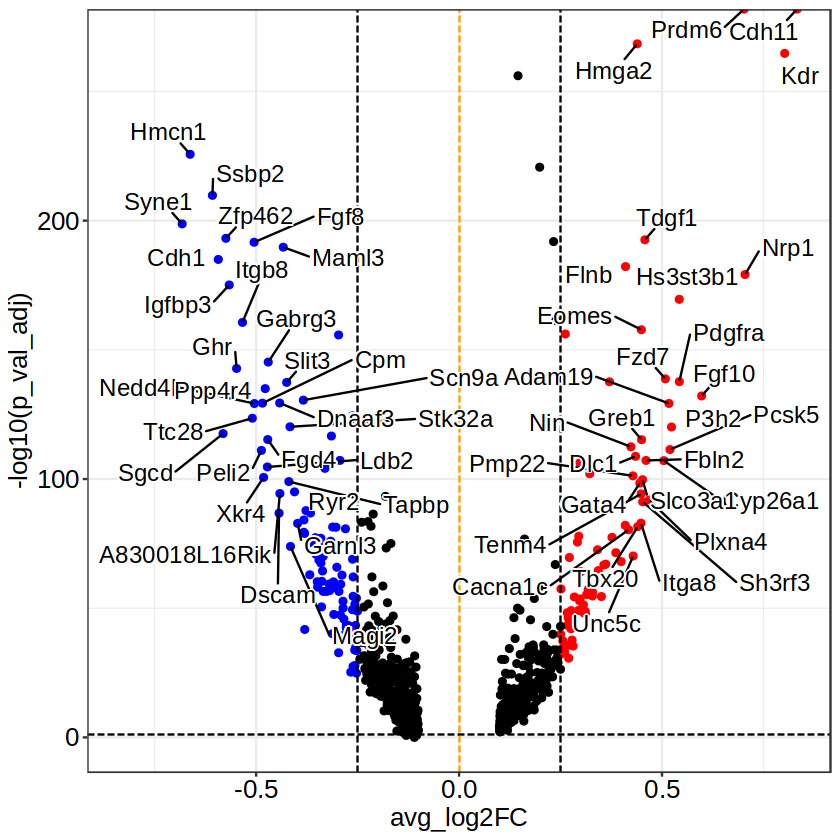

In [9]:
markers = find_DEGs(ct1 = "Early_Mes_EOd", ct2 = "Early_Mes_EOi")
volcano_plot(markers, ntop = 30)

In [10]:
unique(Idents(seurat))

[1] Early_Mes_EOd       Early_Mes_EOi       Primitive_Streak   
 [4] Posterior_Mes       HE_Precursor        HE                 
 [7] Mesenchyme          Allantois_Precursor Blood_Progenitor   
[10] Endothelium         Allantois          
11 Levels: Early_Mes_EOd Early_Mes_EOi Primitive_Streak ... Allantois

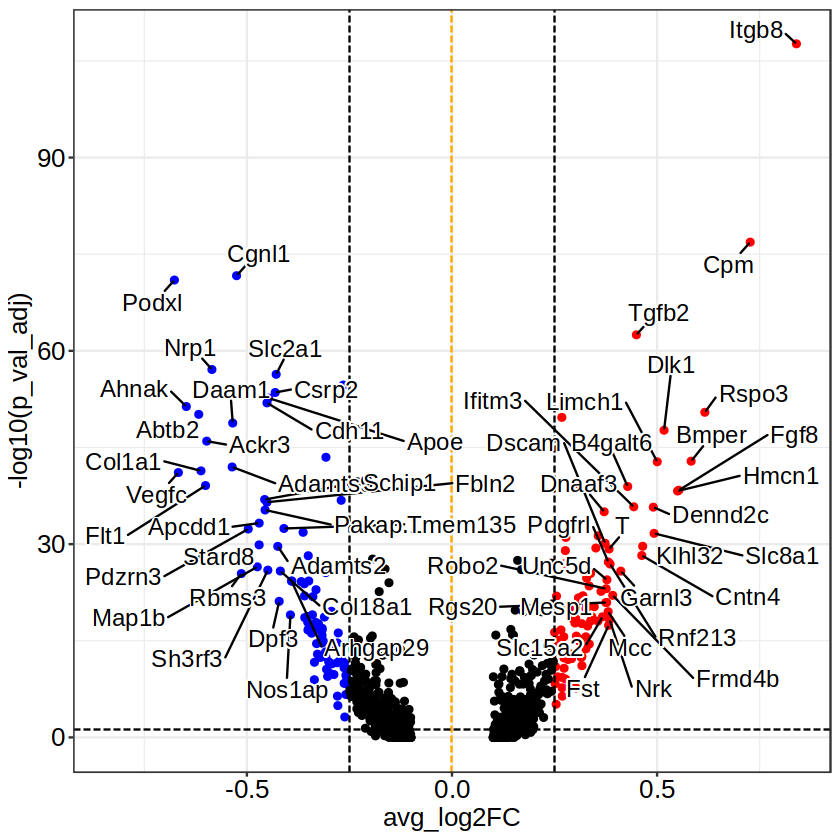

In [11]:
markers = find_DEGs(ct1 = "Posterior_Mes", ct2 = "Mesenchyme")
volcano_plot(markers, ntop = 30)

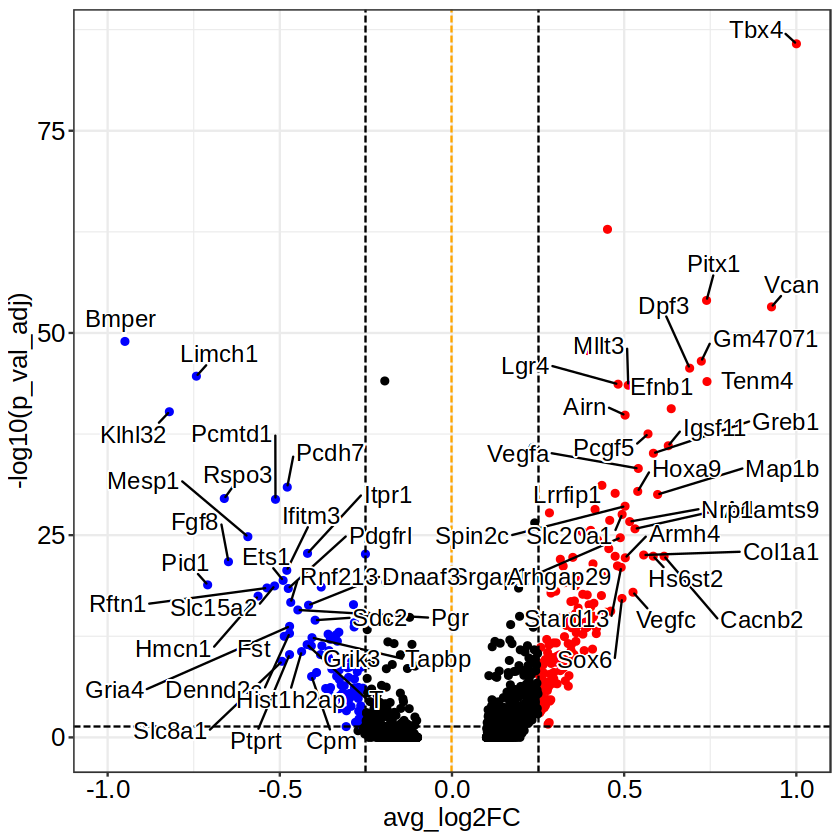

In [12]:
markers = find_DEGs(ct1 = "Allantois_Precursor", ct2 = "Posterior_Mes")
volcano_plot(markers, ntop = 30)

In [13]:
# load cell surface marker list
surface_markers = as.vector(fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/SurfaceGenie_SPC_geneNames.txt', header=F)$V1)
surface_markers = intersect(rownames(seurat), surface_markers)

In [14]:
seurat = seurat[surface_markers,]

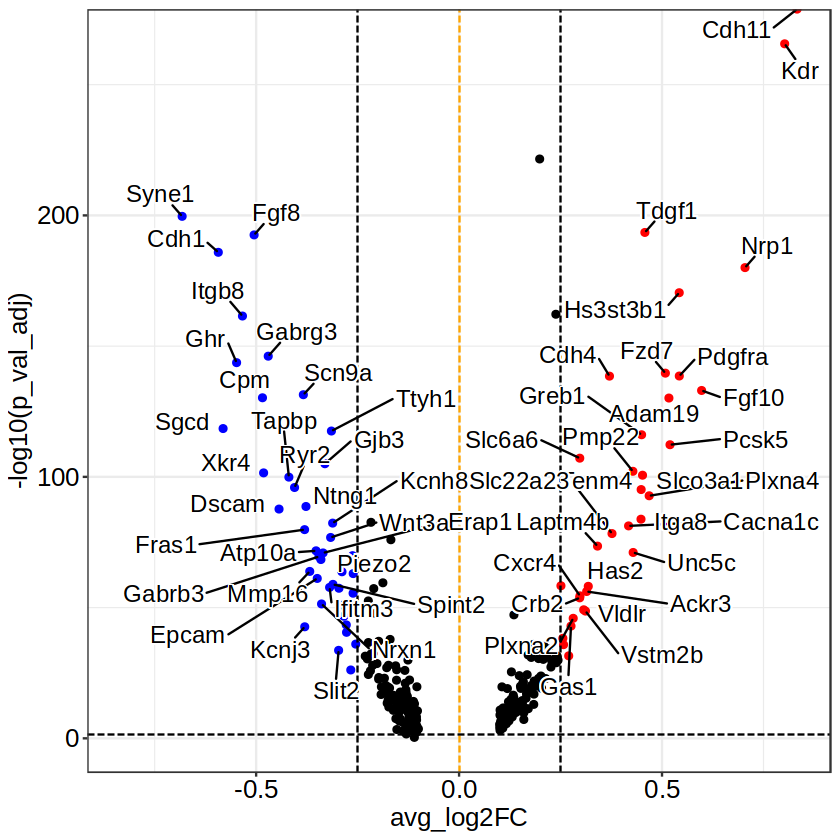

In [15]:
markers = find_DEGs(ct1 = "Early_Mes_EOd", ct2 = "Early_Mes_EOi")
volcano_plot(markers, ntop = 30)

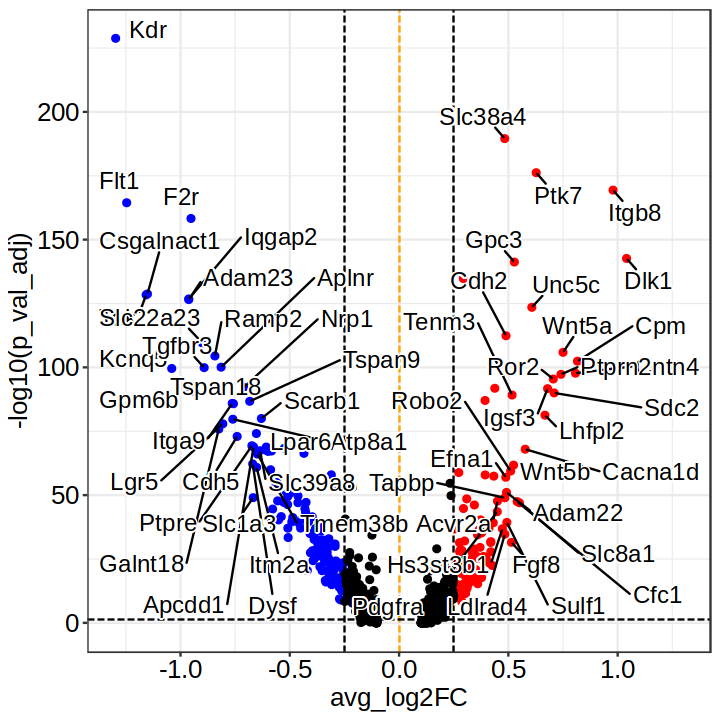

In [16]:
markers = find_DEGs(ct1 = "Posterior_Mes", ct2 = "HE")
options(repr.plot.width=6, repr.plot.height=6)
volcano_plot(markers, ntop = 30)

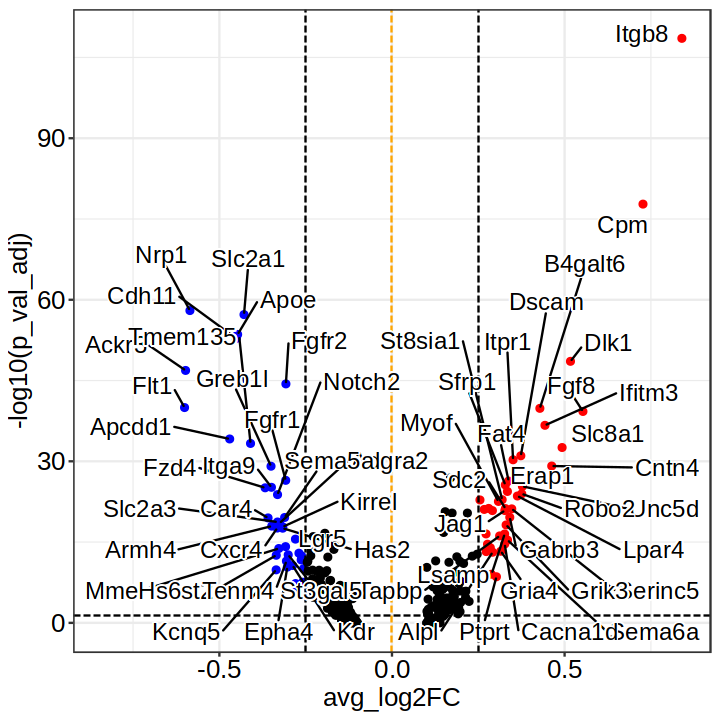

In [17]:
markers = find_DEGs(ct1 = "Posterior_Mes", ct2 = "Mesenchyme")
options(repr.plot.width=6, repr.plot.height=6)
volcano_plot(markers, ntop = 30)

### Trajectory analysis & Tradeseq on MOFA factors

In [24]:
## Load packages
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(tradeSeq))
suppressPackageStartupMessages(library(slingshot))
suppressPackageStartupMessages(library(BiocParallel))

In [25]:
# Load meta
meta = fread(args$metadata)[day%in%c('D3.5', 'D4', 'D4.5', 'D5')] # & genotype=='WT']

In [26]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [27]:
# Prepare mofa umap
umap.mtx = meta[,c('cell', 'UMAP1', 'UMAP2')] %>% 
    as.data.frame(.) %>% 
    tibble::column_to_rownames('cell') %>%
    as.matrix()

In [28]:
mofa = fread(file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_factors.txt.gz')) %>% 
    .[match(colnames(rna.sce), cell),] %>% 
    as.data.frame() %>% tibble::column_to_rownames('cell') %>% 
    as.matrix

In [29]:
# Add mofa factors
reducedDims(rna.sce)$mofa = mofa
# Add mofa umap
reducedDims(rna.sce)$mofa_umap = umap.mtx[match(colnames(rna.sce), rownames(umap.mtx)),]

In [30]:
rna.sce <- slingshot(rna.sce, 
                     clusterLabels = 'celltype_v1', 
                     start.clus = 'Primitive_Streak', 
                     #end.clus = c('HE_Precursor', 'Allantois'),
                     reducedDim='mofa')
head(rna.sce$slingPseudotime_1)

[1] 5.961515 6.562618 5.961311 6.821068 6.798336 6.897043

In [32]:
rna.sce$slingshot

class: PseudotimeOrdering 
dim: 27135 4 
metadata(4): lineages mst slingParams curves
pathStats(2): pseudotime weights
cellnames(27135): 2_Eo_DEG_G9_day3_5_VC#AAACAGCCAAAGCGGC-1
  2_Eo_DEG_G9_day3_5_VC#AAACAGCCAACCTAAT-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
cellData names(2): reducedDim clusterLabels
pathnames(4): Lineage1 Lineage2 Lineage3 Lineage4
pathData names(0):

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


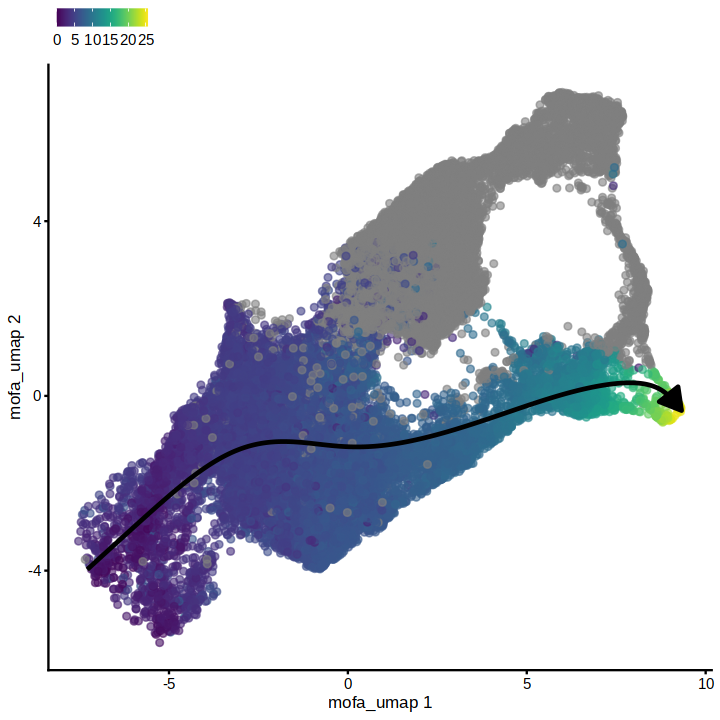

In [33]:
embedded <- embedCurves(rna.sce, "mofa_umap")
embedded <- slingCurves(embedded)[[1]] # only 1 path.
embedded1 <- data.frame(embedded$s[embedded$ord,])

colData(rna.sce)$pseudotime = colData(rna.sce)$slingPseudotime_1 # meta %>% tibble::column_to_rownames("cell") %>% DataFrame

plotReducedDim(rna.sce, dimred = "mofa_umap", colour_by="pseudotime", ncomponents = c(1,2)) +
    geom_path(data=embedded1, 
              aes(x=UMAP1, y=UMAP2), 
              size=1, 
              arrow=grid::arrow(ends = 'last', type = 'closed', length = unit(0.20, "inches"))) + 
    theme(legend.position="top", legend.title = element_blank())

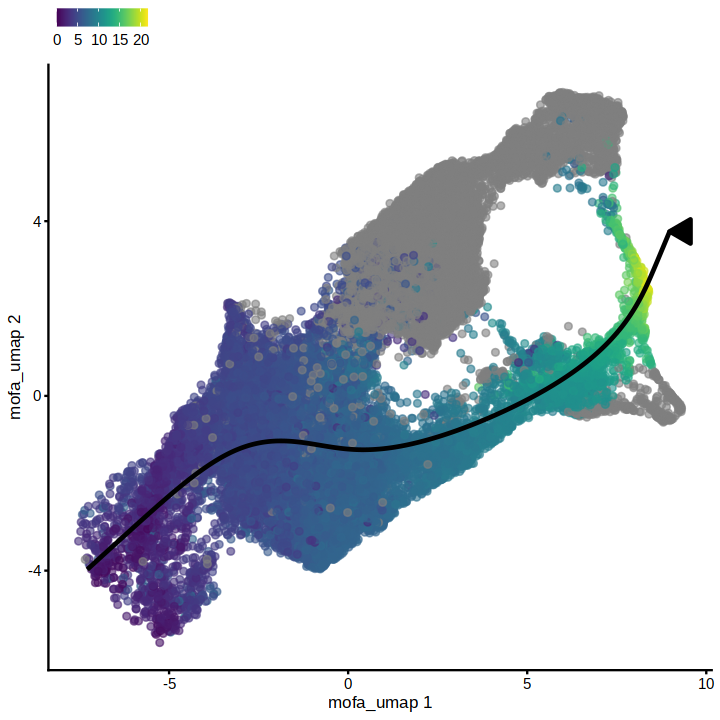

In [34]:
embedded <- embedCurves(rna.sce, "mofa_umap")
embedded <- slingCurves(embedded)[[2]] # only 1 path.
embedded2 <- data.frame(embedded$s[embedded$ord,])

colData(rna.sce)$pseudotime = colData(rna.sce)$slingPseudotime_2 # meta %>% tibble::column_to_rownames("cell") %>% DataFrame

plotReducedDim(rna.sce, dimred = "mofa_umap", colour_by="pseudotime", ncomponents = c(1,2)) +
    geom_path(data=embedded2, 
              aes(x=UMAP1, y=UMAP2), 
              size=1, 
              arrow=grid::arrow(ends = 'last', type = 'closed', length = unit(0.20, "inches"))) + 
    theme(legend.position="top", legend.title = element_blank())

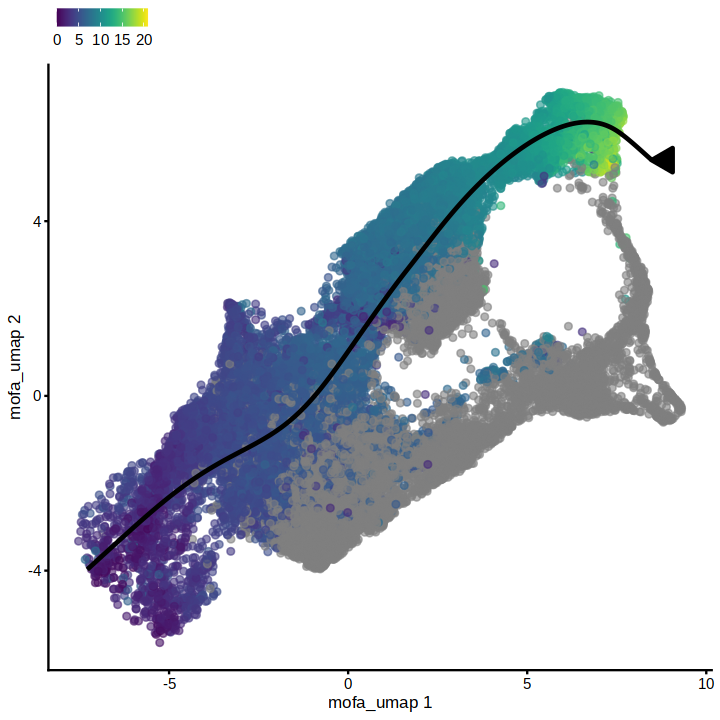

In [35]:
embedded <- embedCurves(rna.sce, "mofa_umap")
embedded <- slingCurves(embedded)[[3]] # only 1 path.
embedded3 <- data.frame(embedded$s[embedded$ord,])

colData(rna.sce)$pseudotime = colData(rna.sce)$slingPseudotime_3 # meta %>% tibble::column_to_rownames("cell") %>% DataFrame

plotReducedDim(rna.sce, dimred = "mofa_umap", colour_by="pseudotime", ncomponents = c(1,2)) +
    geom_path(data=embedded3, 
              aes(x=UMAP1, y=UMAP2), 
              size=1, 
              arrow=grid::arrow(ends = 'last', type = 'closed', length = unit(0.20, "inches"))) + 
    theme(legend.position="top", legend.title = element_blank())

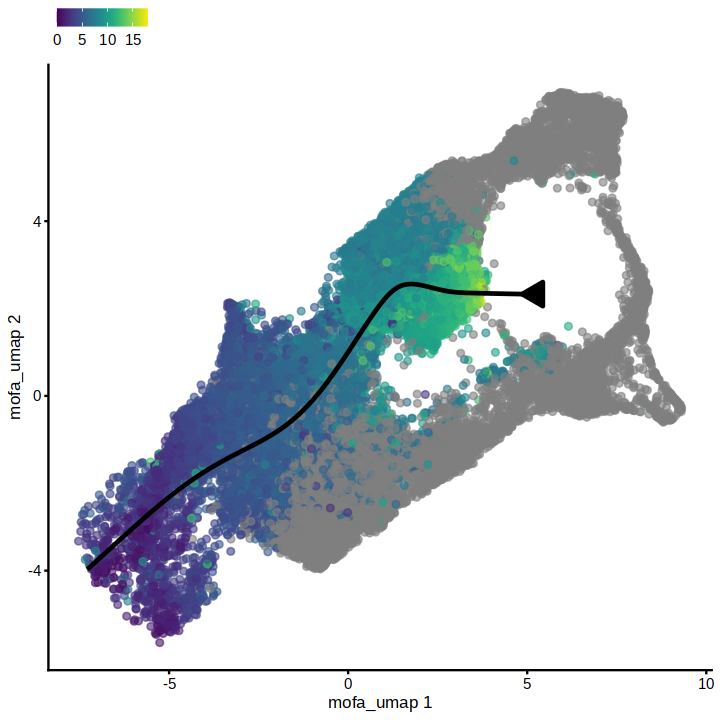

In [36]:
embedded <- embedCurves(rna.sce, "mofa_umap")
embedded <- slingCurves(embedded)[[4]] # only 1 path.
embedded4 <- data.frame(embedded$s[embedded$ord,])

colData(rna.sce)$pseudotime = colData(rna.sce)$slingPseudotime_4 # meta %>% tibble::column_to_rownames("cell") %>% DataFrame

plotReducedDim(rna.sce, dimred = "mofa_umap", colour_by="pseudotime", ncomponents = c(1,2)) +
    geom_path(data=embedded4, 
              aes(x=UMAP1, y=UMAP2), 
              size=1, 
              arrow=grid::arrow(ends = 'last', type = 'closed', length = unit(0.20, "inches"))) + 
    theme(legend.position="top", legend.title = element_blank())

In [38]:
saveRDS(rna.sce$slingshot, file.path(args$outdir, 'slingshot.rds'))

#### Run Trade-seq in R-script

In [ ]:
## Load packages
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(tradeSeq))
suppressPackageStartupMessages(library(slingshot))
suppressPackageStartupMessages(library(BiocParallel))

# Options
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 24

## I/O
args = list()
# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated.txt.gz')
# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')
# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/trajectory/')
# Slingshot
args$slingshot = file.path(args$outdir, 'slingshot.rds')

## Load data
# Load meta
meta = fread(args$metadata)[day%in%c('D3.5', 'D4', 'D4.5', 'D5')] # & genotype=='WT']
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()
# load slingshot
slingshot = readRDS(args$slingshot)

## Filter some genes manually
genes_keep = rownames(rna.sce)
genes_keep <- genes_keep[grep("^Rik|Rik$|^mt-|^Rps|^Rpl|^Gm",genes_keep,invert=T)] # filter out non-informative genes
genes_keep <- genes_keep[grep("^Hbb|^Hba",genes_keep,invert=T)] # test removing Haem genes 
rna.sce = rna.sce[genes_keep,]

# Keep only WT cells
sce_filt = rna.sce[,colData(rna.sce)$genotype == 'WT']

# Only run on top 10k variable genes
args$features = 10000

decomp <- modelGeneVar(sce_filt)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% 
    as.data.table(., keep.rownames=T) %>% 
     head(n=args$features) %>% .$rn

sce_filt = sce_filt[hvgs, ]

# Subset to cells within one of the trajectories
cells_keep = ifelse(pathStats(slingshot)$weights[,1] == 0 & pathStats(slingshot)$weights[,2] == 0, FALSE, TRUE)
pathStats(slingshot)$pseudotime[is.na(pathStats(slingshot)$pseudotime)] = 0
slingshot = slingshot[cells_keep]
sce_filt = sce_filt[, cells_keep]

# Test if same cells object
summary(rownames(slingshot) == colnames(sce_filt))

U <- model.matrix(~sce_filt$replicate)

sceGAM <- fitGAM(counts = counts(sce_filt),
                 pseudotime = pathStats(slingshot)$pseudotime,
                 cellWeights =pathStats(slingshot)$weights,
                 U = U,
                 nknots=4, 
                 parallel = TRUE,
                 BPPARAM=BPPARAM,
                 verbose=F)

saveRDS(sceGAM, paste0(io$outdir,"/sceGAM_WT_Traj1_vs_Traj2.rds"))

In [103]:
# Only interested in WT cells at early stages
rna_tradeseq = rna.sce[,colData(rna.sce)$genotype == 'WT']

# Only interested in comparing trajectory 2 vs 3 at early timepoints
slingshot = rna_tradeseq$slingshot[, c(2,3)]

In [104]:
# Set parallel cores
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 24

In [105]:
# Only run on top 10k variable genes
args$features = 10000

decomp <- modelGeneVar(rna_tradeseq)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% 
    as.data.table(., keep.rownames=T) %>% 
     head(n=args$features) %>% .$rn

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [106]:
sce_filt = rna_tradeseq[hvgs, ]

In [107]:
# Subset to cells within one of the trajectories
cells_keep = ifelse(pathStats(slingshot)$weights[,1] == 0 & pathStats(slingshot)$weights[,2] == 0, FALSE, TRUE)
pathStats(slingshot)$pseudotime[is.na(pathStats(slingshot)$pseudotime)] = 0
slingshot = slingshot[cells_keep]
sce_filt = sce_filt[, cells_keep]

In [109]:
summary(rownames(slingshot) == colnames(sce_filt))

class: PseudotimeOrdering 
dim: 13465 2 
metadata(4): lineages mst slingParams curves
pathStats(2): pseudotime weights
cellnames(13465): 2_Eo_DEG_G9_day3_5_VC#AAACAGCCAAAGCGGC-1
  2_Eo_DEG_G9_day3_5_VC#AAACAGCCAACCTAAT-1 ...
  rv_eo_deg_day4_control#TTTGTGGCATCCCTCA-1
  rv_eo_deg_day4_control#TTTGTGTTCCTGAATA-1
cellData names(2): reducedDim clusterLabels
pathnames(2): Lineage2 Lineage3
pathData names(0):

In [ ]:
## Run in Rscript

# create a model matrix -> Comparing within Embryo pools
U <- model.matrix(~sce_filt$replicate)

sceGAM <- fitGAM(counts = counts(sce_filt),
                 #sds = slingshot,
                 pseudotime = pathStats(slingshot)$pseudotime,
                 cellWeights =pathStats(slingshot)$weights,
                 U = U,
                 nknots=4, 
                 parallel = TRUE,
                 BPPARAM=BPPARAM,
                 verbose=F)

#saveRDS(sceGAM, paste0(io$outdir,"/sceGAM_v1.rds"))

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.0 GiB”


In [413]:
sceGAM

class: SingleCellExperiment 
dim: 100 12661 
metadata(1): tradeSeq
assays(1): counts
rownames(100): Xkr4 Gm1992 ... 6720483E21Rik Paqr8
rowData names(1): tradeSeq
colnames(12661): 2_Eo_DEG_G9_day3_5_VC#AAACAGCCAAAGCGGC-1
  2_Eo_DEG_G9_day3_5_VC#AAACAGCCAACCTAAT-1 ...
  rv_eo_deg_day4_control#TTTGTGGCATCCCTCA-1
  rv_eo_deg_day4_control#TTTGTGTTCCTGAATA-1
colData names(2): crv tradeSeq
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [ ]:
startRes <- startVsEndTest(sceGAM)
oStart <- order(startRes$waldStat, decreasing = TRUE)
sigGeneStart <- names(sceGAM)[oStart[1]]
plotSmoothers(sceGAM, counts(sceGAM), gene = 'Sox17')

In [423]:
rownames(startRes)

[1] "Xkr4"          "Gm1992"        "Gm19938"       "Gm37381"      
  [5] "Rp1"           "Sox17"         "Gm37587"       "Gm37323"      
  [9] "Mrpl15"        "Lypla1"        "Tcea1"         "Rgs20"        
 [13] "Gm16041"       "Atp6v1h"       "Oprk1"         "Npbwr1"       
 [17] "Rb1cc1"        "4732440D04Rik" "Alkal1"        "St18"         
 [21] "Pcmtd1"        "Gm26901"       "Gm30414"       "Sntg1"        
 [25] "Rrs1"          "Adhfe1"        "2610203C22Rik" "Vxn"          
 [29] "Gm29520"       "Mybl1"         "Vcpip1"        "1700034P13Rik"
 [33] "Sgk3"          "Mcmdc2"        "Snhg6"         "Tcf24"        
 [37] "Ppp1r42"       "Gm15818"       "Cops5"         "Cspp1"        
 [41] "Arfgef1"       "Cpa6"          "Prex2"         "A830018L16Rik"
 [45] "Gm17644"       "Gm29663"       "Sulf1"         "Slco5a1"      
 [49] "Gm29283"       "Prdm14"        "Ncoa2"         "Gm29570"      
 [53] "Tram1"         "Lactb2"        "Xkr9"          "Eya1"         
 [57] "Gm9947"        "Msc"           "Trpa1"         "Kcnb2"        
 [61] "Terf1"         "Sbspon"        "4930444P10Rik" "Rpl7"         
 [65] "Rdh10"         "Gm28095"       "Stau2"         "Gm7568"       
 [69] "Ube2w"         "Eloc"          "D030040B21Rik" "Tmem70"       
 [73] "Ly96"          "Gm28376"       "Jph1"          "Gm28783"      
 [77] "Gdap1"         "Gm28784"       "Pi15"          "Gm28154"      
 [81] "Gm16070"       "Crispld1"      "Gm28153"       "Gm28756"      
 [85] "Crisp4"        "Defb18"        "Defb41"        "Gm15825"      
 [89] "Tfap2d"        "Tfap2b"        "Gm28340"       "Pkhd1"        
 [93] "4930486I03Rik" "Gm28653"       "Il17a"         "Il17f"        
 [97] "Mcm3"          "Gm28065"       "6720483E21Rik" "Paqr8"

In [421]:
names(sceGAM)

[1] "Xkr4"          "Gm1992"        "Gm19938"       "Gm37381"      
  [5] "Rp1"           "Sox17"         "Gm37587"       "Gm37323"      
  [9] "Mrpl15"        "Lypla1"        "Tcea1"         "Rgs20"        
 [13] "Gm16041"       "Atp6v1h"       "Oprk1"         "Npbwr1"       
 [17] "Rb1cc1"        "4732440D04Rik" "Alkal1"        "St18"         
 [21] "Pcmtd1"        "Gm26901"       "Gm30414"       "Sntg1"        
 [25] "Rrs1"          "Adhfe1"        "2610203C22Rik" "Vxn"          
 [29] "Gm29520"       "Mybl1"         "Vcpip1"        "1700034P13Rik"
 [33] "Sgk3"          "Mcmdc2"        "Snhg6"         "Tcf24"        
 [37] "Ppp1r42"       "Gm15818"       "Cops5"         "Cspp1"        
 [41] "Arfgef1"       "Cpa6"          "Prex2"         "A830018L16Rik"
 [45] "Gm17644"       "Gm29663"       "Sulf1"         "Slco5a1"      
 [49] "Gm29283"       "Prdm14"        "Ncoa2"         "Gm29570"      
 [53] "Tram1"         "Lactb2"        "Xkr9"          "Eya1"         
 [57] "Gm9947"        "Msc"           "Trpa1"         "Kcnb2"        
 [61] "Terf1"         "Sbspon"        "4930444P10Rik" "Rpl7"         
 [65] "Rdh10"         "Gm28095"       "Stau2"         "Gm7568"       
 [69] "Ube2w"         "Eloc"          "D030040B21Rik" "Tmem70"       
 [73] "Ly96"          "Gm28376"       "Jph1"          "Gm28783"      
 [77] "Gdap1"         "Gm28784"       "Pi15"          "Gm28154"      
 [81] "Gm16070"       "Crispld1"      "Gm28153"       "Gm28756"      
 [85] "Crisp4"        "Defb18"        "Defb41"        "Gm15825"      
 [89] "Tfap2d"        "Tfap2b"        "Gm28340"       "Pkhd1"        
 [93] "4930486I03Rik" "Gm28653"       "Il17a"         "Il17f"        
 [97] "Mcm3"          "Gm28065"       "6720483E21Rik" "Paqr8"